In [1]:
import os
print("Your home directory is:", os.path.expanduser("~"))

Your home directory is: C:\Users\Compu City


In [2]:
# Create .cdsapirc file
import os

home_dir = os.path.expanduser("~")
cdsapirc_path = os.path.join(home_dir, ".cdsapirc")

config_content = """url: https://cds.climate.copernicus.eu/api
key: 7a19fa07-922b-486f-9d0a-6f8a377138ca"""

with open(cdsapirc_path, 'w') as f:
    f.write(config_content)
    
print(f"Created .cdsapirc file at: {cdsapirc_path}")

Created .cdsapirc file at: C:\Users\Compu City\.cdsapirc


In [3]:
# Initialize CMEMS credentials
import subprocess
print("Please run this command in a terminal to set up CMEMS credentials:")
print("\ncopernicus_marine init\n")
print("You will be prompted to enter your CMEMS username and password.")

Please run this command in a terminal to set up CMEMS credentials:

copernicus_marine init

You will be prompted to enter your CMEMS username and password.


In [4]:
# Fix NumPy version compatibility
import subprocess
import sys

# Install compatible version of NumPy
subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy<2.0.0", "--force-reinstall"])

0

In [5]:
# Install required packages
import sys
import subprocess

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

required_packages = ['cdsapi', 'xarray', 'netCDF4', 'cfgrib', 'copernicusmarine']
for package in required_packages:
    try:
        __import__(package)
        print(f"{package} is already installed")
    except ImportError:
        print(f"Installing {package}...")
        install_package(package)

cdsapi is already installed
xarray is already installed
netCDF4 is already installed
xarray is already installed
netCDF4 is already installed
cfgrib is already installed
cfgrib is already installed
copernicusmarine is already installed
copernicusmarine is already installed


# 2. Download ERA5 and CMEMS Data

This notebook will:
1. Set up API access to Copernicus services
2. Download ERA5 atmospheric data (winds)
3. Download CMEMS ocean data (currents)
4. Verify and save the data in NetCDF format

First, ensure you have accounts for:
- Copernicus Climate Data Store (ERA5): https://cds.climate.copernicus.eu/
- Copernicus Marine Service (CMEMS): https://marine.copernicus.eu/

In [6]:
# Load metadata from the first notebook
import json
import os
from datetime import datetime, timedelta

# Load the saved metadata
raw_dir = os.path.join('..', 'data', 'raw')
processed_dir = os.path.join('..', 'data', 'processed')
metadata_files = [f for f in os.listdir(processed_dir) if f.endswith('.metadata.json')]

if metadata_files:
    metadata_path = os.path.join(processed_dir, metadata_files[0])
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    print("Loaded metadata from:", metadata_path)
    
    # Extract coordinates
    bounds = metadata['bounds']
    lat_min, lat_max = bounds['bottom'], bounds['top']
    lon_min, lon_max = bounds['left'], bounds['right']
    
    # Extract date from filename (assuming format YYYY-MM-DD-HH_MM_...)
    filename = metadata_files[0].split('.metadata.json')[0]
    date_str = filename.split('-00_00')[0]  # Get the first part before time
    date = datetime.strptime(date_str, '%Y-%m-%d')
    
    print(f"\nExtracted information:")
    print(f"Date: {date.strftime('%Y-%m-%d')}")
    print(f"Area: {lat_min:.2f}°N to {lat_max:.2f}°N, {lon_min:.2f}°E to {lon_max:.2f}°E")

Loaded metadata from: ..\data\processed\2023-04-23-00_00_2023-04-23-23_59_Sentinel-1_IW_VV+VH_VV_-_decibel_gamma0.tiff.metadata.json

Extracted information:
Date: 2023-04-23
Area: 13.20°N to 13.40°N, 121.40°E to 121.70°E


In [7]:
# Download ERA5 data with proper spatial grid
import cdsapi
import xarray as xr

c = cdsapi.Client()

# Expand the area slightly to ensure we get a proper grid with multiple points
# Add 0.25 degrees padding to create a reasonable grid
lat_padding = 0.25
lon_padding = 0.25
lat_max_padded = lat_max + lat_padding
lat_min_padded = lat_min - lat_padding
lon_max_padded = lon_max + lon_padding
lon_min_padded = lon_min - lon_padding

print(f"Requesting ERA5 data for area:")
print(f"  Latitude: {lat_max_padded:.2f}°N to {lat_min_padded:.2f}°N")
print(f"  Longitude: {lon_min_padded:.2f}°E to {lon_max_padded:.2f}°E")

# Setup the request with proper grid specification
era5_request = {
    'product_type': 'reanalysis',
    'format': 'netcdf',
    'variable': ['10m_u_component_of_wind', '10m_v_component_of_wind'],
    'year': date.strftime('%Y'),
    'month': date.strftime('%m'),
    'day': date.strftime('%d'),
    'time': [f"{h:02d}:00" for h in range(24)],
    'area': [lat_max_padded, lon_min_padded, lat_min_padded, lon_max_padded],
    'grid': [0.25, 0.25],  # 0.25 degree grid resolution (consistent with CMEMS)
}

# Download ERA5 data
era5_output = os.path.join(processed_dir, f'era5_wind_{date.strftime("%Y%m%d")}.nc')
print(f"Downloading ERA5 data to: {era5_output}")

try:
    c.retrieve(
        'reanalysis-era5-single-levels',
        era5_request,
        era5_output
    )
    print("ERA5 download complete!")
    
    # Verify the downloaded data
    era5_ds = xr.open_dataset(era5_output)
    print(f"\nERA5 Data Info:")
    print(f"  Latitude points: {len(era5_ds.latitude)}")
    print(f"  Longitude points: {len(era5_ds.longitude)}")
    print(f"  Time steps: {len(era5_ds.time) if 'time' in era5_ds.dims else len(era5_ds.valid_time)}")
    era5_ds.close()
    
except Exception as e:
    print(f"Error downloading ERA5 data: {e}")
    print("Make sure your CDS API credentials are set up correctly.")

Requesting ERA5 data for area:
  Latitude: 13.65°N to 12.95°N
  Longitude: 121.15°E to 121.95°E


2025-11-28 21:18:38,923 INFO Request ID is 0f88612d-6a66-4490-8d5b-6298db02afd4
2025-11-28 21:18:39,051 INFO status has been updated to accepted
2025-11-28 21:18:39,051 INFO status has been updated to accepted
2025-11-28 21:18:52,722 INFO status has been updated to running
2025-11-28 21:18:52,722 INFO status has been updated to running
2025-11-28 21:19:00,442 INFO status has been updated to successful
2025-11-28 21:19:00,442 INFO status has been updated to successful


8b0895cad38c3dff034e88d98b0472a.nc:   0%|          | 0.00/34.3k [00:00<?, ?B/s]

ERA5 download complete!

ERA5 Data Info:
  Latitude points: 3
  Longitude points: 4
  Time steps: 24


In [8]:
# Download CMEMS ocean current data with same spatial coverage as ERA5
from copernicusmarine import subset

# Use the same padded bounds as ERA5 for consistency
lat_padding = 0.25
lon_padding = 0.25
lat_max_padded = lat_max + lat_padding
lat_min_padded = lat_min - lat_padding
lon_max_padded = lon_max + lon_padding
lon_min_padded = lon_min - lon_padding

# Time range (24 hours for the day of interest)
start_date = f"{date.strftime('%Y-%m-%d')}T00:00:00"
end_date = f"{(date + timedelta(days=1)).strftime('%Y-%m-%d')}T00:00:00"

# Output file
cmems_output = os.path.join(processed_dir, f'cmems_current_{date.strftime("%Y%m%d")}.nc')
print(f"Downloading CMEMS data to: {cmems_output}")
print(f"  Latitude: {lat_max_padded:.2f}°N to {lat_min_padded:.2f}°N")
print(f"  Longitude: {lon_min_padded:.2f}°E to {lon_max_padded:.2f}°E")

try:
    subset(
        dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",  # Global Ocean Physics Reanalysis
        variables=["uo", "vo"],  # Ocean current components
        start_datetime=start_date,
        end_datetime=end_date,
        minimum_latitude=lat_min_padded,
        maximum_latitude=lat_max_padded,
        minimum_longitude=lon_min_padded,
        maximum_longitude=lon_max_padded,
        output_filename=cmems_output
    )
    print("CMEMS download complete!")
    
    # Verify the downloaded data
    cmems_ds = xr.open_dataset(cmems_output)
    print(f"\nCMEMS Data Info:")
    print(f"  Latitude points: {len(cmems_ds.latitude)}")
    print(f"  Longitude points: {len(cmems_ds.longitude)}")
    print(f"  Time steps: {len(cmems_ds.time)}")
    print(f"  Depth levels: {len(cmems_ds.depth)}")
    cmems_ds.close()
    
except Exception as e:
    print(f"Error downloading CMEMS data: {e}")
    print("Make sure your CMEMS credentials are set up correctly.")

  Latitude: 13.65°N to 12.95°N
  Longitude: 121.15°E to 121.95°E


INFO - 2025-11-28T21:19:06Z - Selected dataset version: "202311"
INFO - 2025-11-28T21:19:06Z - Selected dataset part: "default"
INFO - 2025-11-28T21:19:06Z - Selected dataset part: "default"
INFO - 2025-11-28T21:19:09Z - Starting download. Please wait...
INFO - 2025-11-28T21:19:09Z - Starting download. Please wait...


  0%|          | 0/82 [00:00<?, ?it/s]

INFO - 2025-11-28T21:20:05Z - Successfully downloaded to ..\data\processed\cmems_current_20230423.nc


CMEMS download complete!

CMEMS Data Info:
  Latitude points: 8
  Longitude points: 10
  Time steps: 2
  Depth levels: 50


# 3. Verify Downloaded Data

Let's check both datasets to ensure:
1. The data was downloaded correctly
2. The variables are present and properly named
3. The spatial and temporal coverage is correct
4. Units and dimensions are as expected

Loading ERA5 wind data...

ERA5 dataset info:
xarray.Dataset {
dimensions:
	valid_time = 24 ;
	latitude = 3 ;
	longitude = 4 ;

variables:
	float32 u10(valid_time, latitude, longitude) ;
		u10:GRIB_paramId = 165 ;
		u10:GRIB_dataType = an ;
		u10:GRIB_numberOfPoints = 12 ;
		u10:GRIB_typeOfLevel = surface ;
		u10:GRIB_stepUnits = 1 ;
		u10:GRIB_stepType = instant ;
		u10:GRIB_gridType = regular_ll ;
		u10:GRIB_uvRelativeToGrid = 0 ;
		u10:GRIB_NV = 0 ;
		u10:GRIB_Nx = 4 ;
		u10:GRIB_Ny = 3 ;
		u10:GRIB_cfName = unknown ;
		u10:GRIB_cfVarName = u10 ;
		u10:GRIB_gridDefinitionDescription = Latitude/Longitude Grid ;
		u10:GRIB_iDirectionIncrementInDegrees = 0.25 ;
		u10:GRIB_iScansNegatively = 0 ;
		u10:GRIB_jDirectionIncrementInDegrees = 0.25 ;
		u10:GRIB_jPointsAreConsecutive = 0 ;
		u10:GRIB_jScansPositively = 0 ;
		u10:GRIB_latitudeOfFirstGridPointInDegrees = 13.451 ;
		u10:GRIB_latitudeOfLastGridPointInDegrees = 12.95 ;
		u10:GRIB_longitudeOfFirstGridPointInDegrees = 121.153 ;
		u10:

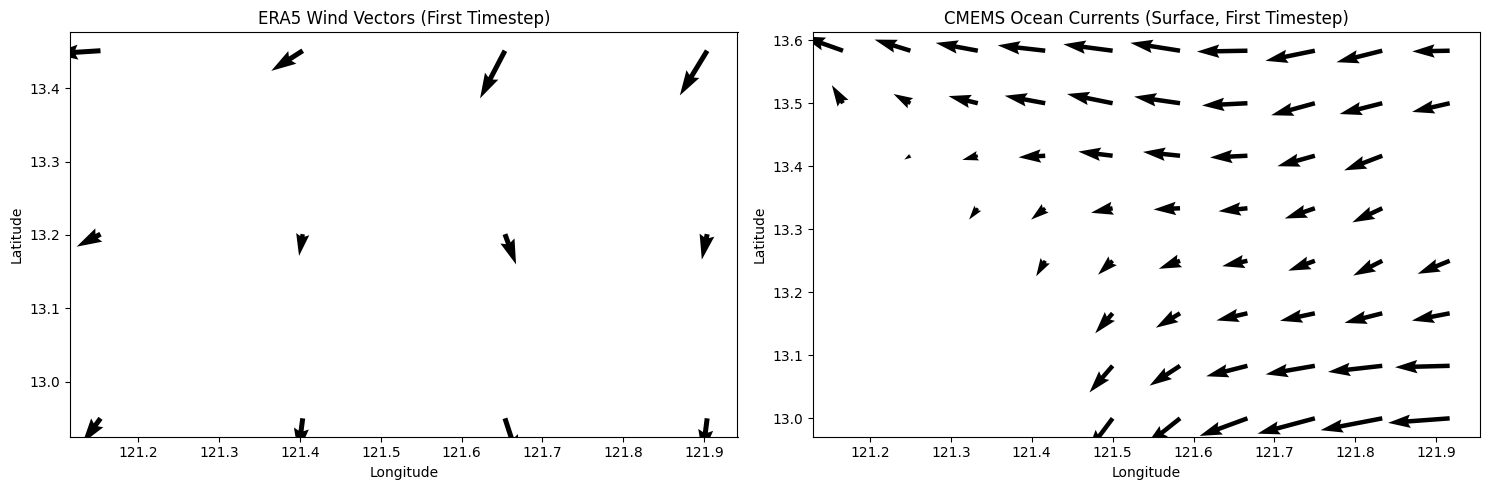


CMEMS Surface Currents Statistics:
Eastward current (uo) range: -0.22 to -0.02 m/s
Northward current (vo) range: -0.12 to 0.06 m/s

Verification results saved to: ..\data\processed\data_verification_20230423.json


C:\Users\Compu City\AppData\Local\Temp\ipykernel_17324\2931041384.py:67: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dimensions': {dim: int(size) for dim, size in era5_ds.dims.items()},
<frozen _collections_abc>:894: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
C:\Users\Compu City\AppData\Local\Temp\ipykernel_17324\2931041384.py:75: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dimensions

In [12]:
# Load and check the downloaded data
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# Load the datasets
print("Loading ERA5 wind data...")
era5_ds = xr.open_dataset(era5_output)
print("\nERA5 dataset info:")
print(era5_ds.info())
print("\nERA5 dimensions:", era5_ds.dims)
print("ERA5 variables:", list(era5_ds.variables))

# Get the correct time dimension name for ERA5
time_dim = 'valid_time' if 'valid_time' in era5_ds.dims else 'time'
print(f"\nUsing time dimension: {time_dim}")

print("\nLoading CMEMS ocean current data...")
cmems_ds = xr.open_dataset(cmems_output)
print("\nCMEMS dataset info:")
print(cmems_ds.info())
print("\nCMEMS dimensions:", cmems_ds.dims)
print("CMEMS variables:", list(cmems_ds.variables))
print("\nCMEMS depth levels:", cmems_ds.depth.values)

# Plot wind and current vectors for the first timestep
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot ERA5 winds
u_var = 'u10' if 'u10' in era5_ds.variables else 'u'
v_var = 'v10' if 'v10' in era5_ds.variables else 'v'

# Get first timestep data for ERA5
u10 = era5_ds[u_var].isel(**{time_dim: 0}) if time_dim in era5_ds.dims else era5_ds[u_var]
v10 = era5_ds[v_var].isel(**{time_dim: 0}) if time_dim in era5_ds.dims else era5_ds[v_var]

# Plot ERA5 winds
lon, lat = np.meshgrid(era5_ds.longitude, era5_ds.latitude)
ax1.quiver(lon, lat, u10, v10)
ax1.set_title('ERA5 Wind Vectors (First Timestep)')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

# Plot CMEMS currents (surface level, depth=0)
uo = cmems_ds['uo'].isel(time=0, depth=0)  # Select first time step and surface level
vo = cmems_ds['vo'].isel(time=0, depth=0)  # Select first time step and surface level

# Create grid for CMEMS
lon, lat = np.meshgrid(cmems_ds.longitude, cmems_ds.latitude)
ax2.quiver(lon, lat, uo, vo)
ax2.set_title('CMEMS Ocean Currents (Surface, First Timestep)')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

# Print some statistics about the currents
print("\nCMEMS Surface Currents Statistics:")
print(f"Eastward current (uo) range: {uo.min().values:.2f} to {uo.max().values:.2f} m/s")
print(f"Northward current (vo) range: {vo.min().values:.2f} to {vo.max().values:.2f} m/s")

# Save the verification results
verification = {
    'era5': {
        'variables': list(era5_ds.variables),
        'dimensions': {dim: int(size) for dim, size in era5_ds.dims.items()},
        'spatial_coverage': {
            'lat': [float(era5_ds.latitude.min()), float(era5_ds.latitude.max())],
            'lon': [float(era5_ds.longitude.min()), float(era5_ds.longitude.max())]
        }
    },
    'cmems': {
        'variables': list(cmems_ds.variables),
        'dimensions': {dim: int(size) for dim, size in cmems_ds.dims.items()},
        'spatial_coverage': {
            'lat': [float(cmems_ds.latitude.min()), float(cmems_ds.latitude.max())],
            'lon': [float(cmems_ds.longitude.min()), float(cmems_ds.longitude.max())]
        },
        'depth_levels': [float(d) for d in cmems_ds.depth.values]
    }
}

# Save verification results
verification_file = os.path.join(processed_dir, f'data_verification_{date.strftime("%Y%m%d")}.json')
with open(verification_file, 'w') as f:
    json.dump(verification, f, indent=2)

print(f"\nVerification results saved to: {verification_file}")

# Close the datasets
era5_ds.close()
cmems_ds.close()

In [10]:
# List available datasets
print("Listing available CMEMS datasets...")
import copernicusmarine

# Use describe without specific product to see all available products
print("\nAvailable ocean physics products:")
try:
    # Try to get a list of all products
    copernicusmarine.describe()
except Exception as e:
    print("\nNote: You might need to run 'copernicus_marine init' in the terminal first if you haven't already.")

Listing available CMEMS datasets...

Available ocean physics products:


Fetching catalogue 1: 100%|██████████| 2/2 [00:44<00:00, 22.34s/it]



In [11]:
# List available datasets
import copernicusmarine

# Search for global ocean physics datasets
print("Searching for available ocean physics datasets...")
copernicusmarine.describe(product="GLOBAL_REANALYSIS_PHY")

Searching for available ocean physics datasets...


TypeError: describe() got an unexpected keyword argument 'product'